In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D 
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.preprocessing import image 
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
test_path = r"C:\Users\MURSHID\Downloads\test_set\test_set"
train_path = r"C:\Users\MURSHID\Downloads\training_set\training_set"

In [6]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [7]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode = 'binary'
)
print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [15]:
# Load testing dataset
test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [16]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

In [17]:
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [18]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# step 5: early stopping

es = EarlyStopping(
    monitor='val_loss',   
    patience=3,          
    restore_best_weights=True  
)

In [21]:
# step 6: train model

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[es]
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 569ms/step - accuracy: 0.5816 - loss: 0.6940 - val_accuracy: 0.6738 - val_loss: 0.6309
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 136s 543ms/step - accuracy: 0.6553 - loss: 0.6279 - val_accuracy: 0.7044 - val_loss: 0.5796
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 134s 534ms/step - accuracy: 0.6876 - loss: 0.5913 - val_accuracy: 0.7365 - val_loss: 0.5453
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 134s 534ms/step - accuracy: 0.7164 - loss: 0.5571 - val_accuracy: 0.7449 - val_loss: 0.5347
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 144s 572ms/step - accuracy: 0.7320 - loss: 0.5341 - val_accuracy: 0.7355 - val_loss: 0.5485
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 156s 621ms/step - accuracy: 0.7530 - loss: 0.5060 - val_accuracy: 0.7726 - val_loss: 0.4973
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 143s 568ms/step - accuracy: 0.7665 - loss: 0.4867 - val_accuracy: 0.7835 - val_loss: 0.4765
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 142s 566ms/step - accuracy: 0.7795 -

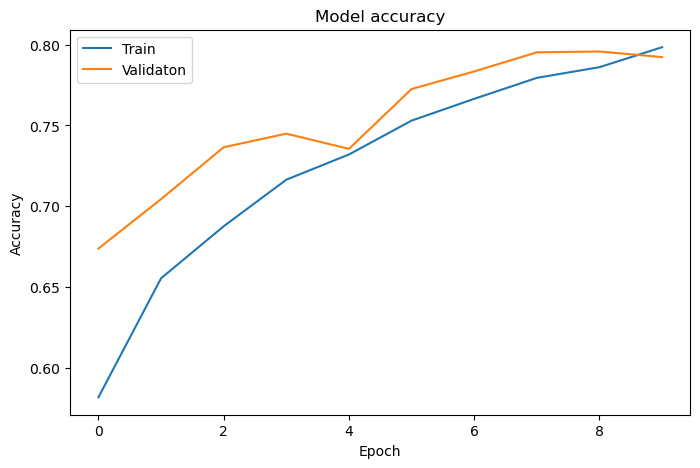

In [22]:
#  step 7: accuracy graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validaton"])

plt.show()

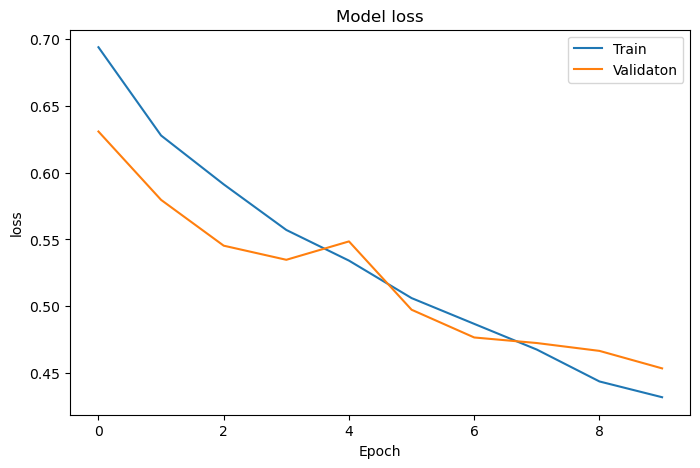

In [23]:
# step 8 : loos graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss' ])
plt.plot(history.history['val_loss' ])

plt.title("Model loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend(["Train","Validaton"])

plt.show()

In [25]:
# Step 9: Evaluate Model

loss, acc = model.evaluate(test_data)

print("Accuracy :", acc)
print("Loss :", loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.7924 - loss: 0.4534
Accuracy : 0.7923875451087952
Loss : 0.4533618092536926


In [26]:
#Step 10: Save Model

model.save("cat_dog_cnn.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


In [27]:
# step 11: load model

model = load_model("cat_dog_cnn.h5")

In [31]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

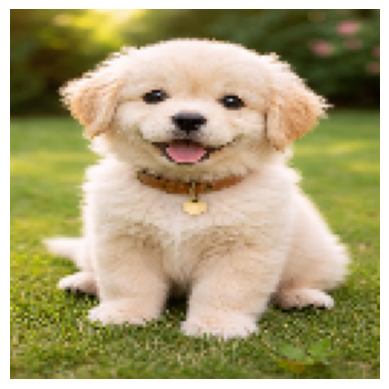

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Prediction Score: 0.99725366


In [32]:
#  step 12: predict new image

img_path = r"C:\Users\MURSHID\Downloads\download (1).jpg"

img = image.load_img(img_path, target_size=(128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis=0)

pred = model.predict(img_arr)

print("Prediction Score:", pred[0][0])

In [33]:
if pred[0][0] >0.5:
    print("dog")
else:
    print("cat")

dog


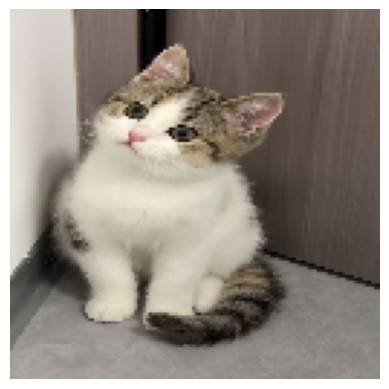

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
prediction score: 0.07774733
cat


In [35]:
model = load_model("cat_dog_cnn.h5")

img_path = r"C:\Users\MURSHID\Downloads\download (2).jpg"

img = image.load_img(img_path,target_size=(128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr,axis=0)

pred = model.predict(img_arr)

print("prediction score:",pred[0][0])

if pred[0][0] >0.5:
    print("dog")
else:
    print("cat")